In [1]:
import os
import gc
import json
import numpy as np
import pandas as pd
import xarray as xr
import multiprocessing as mp

from pathlib import Path
from tqdm.auto import tqdm


In [2]:
DATA_ROOT = Path("/g/data/x77/ha2606/HeatScale-AU-Data")
ERA5_OUT = DATA_ROOT / "ERA5"

ERA5_OUT.mkdir(
    parents=True,
    exist_ok=True
)

ERA5_OUT

PosixPath('/g/data/x77/ha2606/HeatScale-AU-Data/ERA5')

In [3]:
ERA5_CSV = "ERA5.csv.gz"

ERA5 = pd.read_csv(
    ERA5_CSV,
    compression="gzip",
    parse_dates=["datetime"]
)

ERA5 = ERA5[
    ["datetime", "variable", "path"]
].copy()

ERA5 = ERA5.sort_values(
    ["datetime", "variable"]
).reset_index(drop=True)

ERA5.head()

,datetime,variable,path
0,1979-01-01,10u,/g/data/rt52/era5/single-levels/reanalysis/10u...
1,1979-01-01,10v,/g/data/rt52/era5/single-levels/reanalysis/10v...
2,1979-01-01,2d,/g/data/rt52/era5/single-levels/reanalysis/2d/...
3,1979-01-01,2t,/g/data/rt52/era5/single-levels/reanalysis/2t/...
4,1979-01-01,msdwlwrf,/g/data/rt52/era5/single-levels/reanalysis/msd...


In [19]:
TARGET_VARIABLES = [
    "tas",
    "huss",
    "ps",
    "uas",
    "vas",
    "rsds",
    "rsus",
    "rlds",
    "rlus",
]

ERA5_SOURCE_VARIABLES = [
    "2t",
    "2d",
    "sp",
    "10u",
    "10v",
    "msdwswrf",
    "msnswrf",
    "msdwlwrf",
    "msnlwrf",
]

ERA5_TO_TARGET = {
    "tas":  "2t",

    # derived:
    "huss": ("2d", "sp"),

    "ps":   "sp",
    "uas":  "10u",
    "vas":  "10v",

    "rsds": "msdwswrf",

    # SW up = SW down - SW net
    "rsus": ("msdwswrf", "msnswrf"),

    "rlds": "msdwlwrf",

    # LW up = LW down - LW net
    "rlus": ("msdwlwrf", "msnlwrf"),
}

BARRAC2_LTLN = {
    "lat_min": -45.69,
    "lat_max": -5.01,
    "lon_min": 108.02,
    "lon_max": 159.90,
    "dim": {
        "lat": 1018,
        "lon": 1298
    }
}

BBOX = {
    "lat_min": BARRAC2_LTLN["lat_min"],
    "lat_max": BARRAC2_LTLN["lat_max"],
    "lon_min": BARRAC2_LTLN["lon_min"],
    "lon_max": BARRAC2_LTLN["lon_max"],
}

BBOX, TARGET_VARIABLES

({'lat_min': -45.69, 'lat_max': -5.01, 'lon_min': 108.02, 'lon_max': 159.9},
 ['tas', 'huss', 'ps', 'uas', 'vas', 'rsds', 'rsus', 'rlds', 'rlus'])

In [21]:
ERA5["year"] = ERA5["datetime"].dt.year

YEARS = sorted(
    ERA5["year"].unique()
)

print(
    YEARS[0],
    YEARS[-1],
    len(YEARS)
)

ERA5.groupby(
    ["year", "variable"]
)["datetime"].nunique().unstack()

1979 2026 48


variable,10u,10v,2d,2t,msdwlwrf,msdwswrf,msnlwrf,msnswrf,sp
year,,,,,,,,,
1979,8760,8760,8760,8760,8760,8760,8760,8760,8760
1980,8784,8784,8784,8784,8784,8784,8784,8784,8784
1981,8760,8760,8760,8760,8760,8760,8760,8760,8760
1982,8760,8760,8760,8760,8760,8760,8760,8760,8760
1983,8760,8760,8760,8760,8760,8760,8760,8760,8760
1984,8784,8784,8784,8784,8784,8784,8784,8784,8784
1985,8760,8760,8760,8760,8760,8760,8760,8760,8760
1986,8760,8760,8760,8760,8760,8760,8760,8760,8760
1987,8760,8760,8760,8760,8760,8760,8760,8760,8760


In [24]:
def audit_year_times(df, year):

    d = df[
        df["datetime"].dt.year == year
    ]

    time_sets = {}

    for var in ERA5_SOURCE_VARIABLES:

        times = pd.DatetimeIndex(
            d.loc[
                d["variable"] == var,
                "datetime"
            ].unique()
        ).sort_values()

        time_sets[var] = times

    reference = time_sets[
        ERA5_SOURCE_VARIABLES[0]
    ]

    for var in ERA5_SOURCE_VARIABLES[1:]:

        if not reference.equals(
            time_sets[var]
        ):
            raise ValueError(
                f"{year}: datetime mismatch "
                f"between {ERA5_SOURCE_VARIABLES[0]} "
                f"and {var}"
            )

    # Check strict hourly continuity
    delta = np.diff(
        reference.values
    ).astype("timedelta64[h]")

    if not np.all(
        delta == np.timedelta64(1, "h")
    ):
        raise ValueError(
            f"{year}: datetime sequence is not "
            f"strictly hourly"
        )

    return reference

times_1979 = audit_year_times(
    ERA5,
    1979
)

print(times_1979[0])
print(times_1979[-1])
print(len(times_1979))

test_path = ERA5.loc[
    ERA5["variable"] == "2t",
    "path"
].iloc[0]

print(test_path)

with xr.open_dataset(
    test_path,
    decode_times=True,
    cache=False
) as ds:

    print(ds)
    
    print("\nDATA VARIABLES:")
    for name, da in ds.data_vars.items():
        print(
            name,
            da.dims,
            da.shape,
            da.attrs.get("units")
        )

1979-01-01 00:00:00
1979-12-31 23:00:00
8760
/g/data/rt52/era5/single-levels/reanalysis/2t/1979/2t_era5_oper_sfc_19790101-19790131.nc


Matplotlib is building the font cache; this may take a moment.


<xarray.Dataset> Size: 6GB
Dimensions:    (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 6kB 1979-01-01 ... 1979-01-31T23:00:00
Data variables:
    t2m        (time, latitude, longitude) float64 6GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-10-04 20:19:05 UTC+1100 by era5_replication_tools-1.2....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis 2m_temperature 19790101-19790131

DATA VARIABLES:
t2m ('time', 'latitude', 'longitude') (744, 721, 1440) K


In [25]:
def find_main_data_variable(ds):

    candidates = []

    for name, da in ds.data_vars.items():

        if (
            "time" in da.dims
            and "latitude" in da.dims
            and "longitude" in da.dims
        ):
            candidates.append(name)

    if len(candidates) != 1:
        raise ValueError(
            f"Expected exactly one main data variable; "
            f"found {candidates}"
        )

    return candidates[0]

with xr.open_dataset(
    test_path,
    decode_times=True,
    cache=False
) as ds:

    lat = ds["latitude"].values
    lon = ds["longitude"].values

    lat_idx = np.where(
        (lat >= BBOX["lat_min"]) &
        (lat <= BBOX["lat_max"])
    )[0]

    lon_idx = np.where(
        (lon >= BBOX["lon_min"]) &
        (lon <= BBOX["lon_max"])
    )[0]

    ERA5_LAT = lat[
        lat_idx[0]:
        lat_idx[-1] + 1
    ]

    ERA5_LON = lon[
        lon_idx[0]:
        lon_idx[-1] + 1
    ]

print(
    "ERA5 cropped shape:",
    len(ERA5_LAT),
    len(ERA5_LON)
)

print(
    "Latitude:",
    ERA5_LAT.min(),
    ERA5_LAT.max()
)

print(
    "Longitude:",
    ERA5_LON.min(),
    ERA5_LON.max()
)


ERA5 cropped shape: 162 207
Latitude: -45.5 -5.25
Longitude: 108.25 159.75


In [27]:
np.savez(
    ERA5_OUT / "metadata.npz",

    variables=np.array(
        TARGET_VARIABLES
    ),

    latitude=np.asarray(
        ERA5_LAT,
        dtype=np.float32
    ),

    longitude=np.asarray(
        ERA5_LON,
        dtype=np.float32
    ),

    bbox=np.array([
        BBOX["lat_min"],
        BBOX["lat_max"],
        BBOX["lon_min"],
        BBOX["lon_max"],
    ], dtype=np.float32)
)

meta = np.load(
    ERA5_OUT / "metadata.npz"
)

print(meta["variables"])
print(meta["latitude"].shape)
print(meta["longitude"].shape)

['tas' 'huss' 'ps' 'uas' 'vas' 'rsds' 'rsus' 'rlds' 'rlus']
(162,)
(207,)


In [28]:
%%writefile era5_process_worker.py

import gc
import numpy as np
import pandas as pd
import xarray as xr


TARGET_VARIABLES = [
    "tas",
    "huss",
    "ps",
    "uas",
    "vas",
    "rsds",
    "rsus",
    "rlds",
    "rlus",
]


def find_main_data_variable(ds):

    candidates = []

    for name, da in ds.data_vars.items():

        if (
            "time" in da.dims
            and "latitude" in da.dims
            and "longitude" in da.dims
        ):
            candidates.append(name)

    if len(candidates) != 1:

        raise ValueError(
            f"Expected one main variable, "
            f"found: {candidates}"
        )

    return candidates[0]


def huss_from_dewpoint(td, ps):
    """
    ERA5 2-m specific humidity from:
        td = 2-m dewpoint temperature [K]
        ps = surface pressure [Pa]

    ECMWF Tetens saturation-over-water formulation.

    Returns:
        specific humidity [kg kg-1]
    """

    td = td.astype(
        np.float64,
        copy=False
    )

    ps = ps.astype(
        np.float64,
        copy=False
    )

    # ECMWF constants
    Rd = 287.0597
    Rv = 461.5250

    a1 = 611.21
    a3 = 17.502
    a4 = 32.19
    T0 = 273.16

    epsilon = Rd / Rv

    # Actual vapour pressure equals saturation
    # vapour pressure at dewpoint temperature.
    e = a1 * np.exp(
        a3 * (td - T0) /
        (td - a4)
    )

    q = (
        epsilon * e
        /
        (
            ps
            - (1.0 - epsilon) * e
        )
    )

    return q.astype(
        np.float32
    )


def load_era5_variable(
    paths,
    target_times,
    bbox
):
    """
    Load one ERA5 source variable for one month.

    Multiple paths are supported in case a month is
    split across more than one NetCDF file.
    """

    target_times = pd.DatetimeIndex(
        target_times
    )

    pieces = []

    expected_lat = None
    expected_lon = None

    for path in paths:

        with xr.open_dataset(
            path,
            decode_times=True,
            cache=False
        ) as ds:

            varname = find_main_data_variable(
                ds
            )

            da = ds[varname]

            file_times = pd.DatetimeIndex(
                pd.to_datetime(
                    ds["time"].values
                )
            )

            # Times from this file that belong to
            # the requested month.
            mask = file_times.isin(
                target_times
            )

            idx_time = np.where(
                mask
            )[0]

            if len(idx_time) == 0:
                continue

            lat = ds[
                "latitude"
            ].values

            lon = ds[
                "longitude"
            ].values

            lat_idx = np.where(
                (lat >= bbox["lat_min"]) &
                (lat <= bbox["lat_max"])
            )[0]

            lon_idx = np.where(
                (lon >= bbox["lon_min"]) &
                (lon <= bbox["lon_max"])
            )[0]

            if (
                len(lat_idx) == 0
                or len(lon_idx) == 0
            ):
                raise ValueError(
                    f"No cells inside bbox: {path}"
                )

            lat_slice = slice(
                lat_idx[0],
                lat_idx[-1] + 1
            )

            lon_slice = slice(
                lon_idx[0],
                lon_idx[-1] + 1
            )

            this_lat = lat[
                lat_slice
            ]

            this_lon = lon[
                lon_slice
            ]

            if expected_lat is None:

                expected_lat = this_lat
                expected_lon = this_lon

            else:

                if not np.array_equal(
                    expected_lat,
                    this_lat
                ):
                    raise ValueError(
                        f"Latitude grid mismatch: {path}"
                    )

                if not np.array_equal(
                    expected_lon,
                    this_lon
                ):
                    raise ValueError(
                        f"Longitude grid mismatch: {path}"
                    )

            # Usually the required times are contiguous.
            if np.all(
                np.diff(idx_time) == 1
            ):

                time_selector = slice(
                    idx_time[0],
                    idx_time[-1] + 1
                )

            else:

                time_selector = idx_time

            values = da.isel(
                time=time_selector,
                latitude=lat_slice,
                longitude=lon_slice
            ).values

            values = np.asarray(
                values,
                dtype=np.float32
            )

            selected_times = file_times[
                idx_time
            ]

            pieces.append(
                (
                    selected_times,
                    values
                )
            )

    if len(pieces) == 0:

        raise ValueError(
            "No matching data found"
        )

    all_times = pd.DatetimeIndex(
        np.concatenate([
            p[0].values
            for p in pieces
        ])
    )

    all_data = np.concatenate(
        [
            p[1]
            for p in pieces
        ],
        axis=0
    )

    order = np.argsort(
        all_times.values
    )

    all_times = all_times[
        order
    ]

    all_data = all_data[
        order
    ]

    if not all_times.equals(
        target_times
    ):

        missing = target_times.difference(
            all_times
        )

        extra = all_times.difference(
            target_times
        )

        raise ValueError(
            f"Datetime mismatch. "
            f"Missing={len(missing)}, "
            f"extra={len(extra)}"
        )

    return all_data


def process_month(task):

    year = task["year"]
    month = task["month"]

    try:

        times = pd.DatetimeIndex(
            task["times"]
        )

        paths = task[
            "paths"
        ]

        bbox = task[
            "bbox"
        ]

        output_path = task[
            "output_path"
        ]

        start = task[
            "start"
        ]

        stop = task[
            "stop"
        ]

        # ------------------------------------------------
        # Load native ERA5 inputs
        # ------------------------------------------------

        t2 = load_era5_variable(
            paths["2t"],
            times,
            bbox
        )

        td2 = load_era5_variable(
            paths["2d"],
            times,
            bbox
        )

        sp = load_era5_variable(
            paths["sp"],
            times,
            bbox
        )

        u10 = load_era5_variable(
            paths["10u"],
            times,
            bbox
        )

        v10 = load_era5_variable(
            paths["10v"],
            times,
            bbox
        )

        sw_down = load_era5_variable(
            paths["msdwswrf"],
            times,
            bbox
        )

        sw_net = load_era5_variable(
            paths["msnswrf"],
            times,
            bbox
        )

        lw_down = load_era5_variable(
            paths["msdwlwrf"],
            times,
            bbox
        )

        lw_net = load_era5_variable(
            paths["msnlwrf"],
            times,
            bbox
        )

        # ------------------------------------------------
        # Convert into BARRA-compatible variable set
        # ------------------------------------------------

        tas = t2

        huss = huss_from_dewpoint(
            td2,
            sp
        )

        ps = sp

        uas = u10
        vas = v10

        rsds = sw_down

        # ECMWF net flux is downward positive:
        # net = downward - upward
        rsus = (
            sw_down
            - sw_net
        )

        rlds = lw_down

        rlus = (
            lw_down
            - lw_net
        )

        # ------------------------------------------------
        # Final order:
        #
        # tas
        # huss
        # ps
        # uas
        # vas
        # rsds
        # rsus
        # rlds
        # rlus
        # ------------------------------------------------

        data = np.stack(
            [
                tas,
                huss,
                ps,
                uas,
                vas,
                rsds,
                rsus,
                rlds,
                rlus,
            ],
            axis=1
        ).astype(
            np.float32,
            copy=False
        )

        # Expected:
        # time × variable × lat × lon

        if data.shape[1] != 9:

            raise ValueError(
                f"Wrong variable dimension: "
                f"{data.shape}"
            )

        if data.shape[0] != len(
            times
        ):

            raise ValueError(
                f"Wrong time dimension: "
                f"{data.shape}"
            )

        # ------------------------------------------------
        # Write directly into the yearly NumPy memmap.
        #
        # No huge data array is returned to parent.
        # ------------------------------------------------

        mm = np.load(
            output_path,
            mmap_mode="r+"
        )

        mm["data"][
            start:stop
        ] = data

        mm.flush()

        del mm
        del data

        del (
            t2,
            td2,
            sp,
            u10,
            v10,
            sw_down,
            sw_net,
            lw_down,
            lw_net,
        )

        gc.collect()

        return {
            "year": year,
            "month": month,
            "n_times": len(times),
            "status": "OK",
            "error": None,
        }

    except Exception as e:

        return {
            "year": year,
            "month": month,
            "n_times": 0,
            "status": "FAILED",
            "error": repr(e),
        }

Writing era5_process_worker.py


In [30]:
import importlib
import era5_process_worker

importlib.reload(era5_process_worker)

from era5_process_worker import process_month

In [31]:
def build_year_tasks(
    df,
    year,
    output_path
):

    year_df = df[
        df["datetime"].dt.year == year
    ].copy()

    year_times = audit_year_times(
        df,
        year
    )

    tasks = []

    for month in sorted(
        year_times.month.unique()
    ):

        month_times = year_times[
            year_times.month == month
        ]

        positions = np.where(
            year_times.month == month
        )[0]

        start = int(
            positions[0]
        )

        stop = int(
            positions[-1] + 1
        )

        month_df = year_df[
            year_df["datetime"].dt.month
            == month
        ]

        path_map = {}

        for var in ERA5_SOURCE_VARIABLES:

            paths = (
                month_df.loc[
                    month_df["variable"] == var,
                    "path"
                ]
                .drop_duplicates()
                .tolist()
            )

            if len(paths) == 0:

                raise ValueError(
                    f"{year}-{month:02d}: "
                    f"no path found for {var}"
                )

            path_map[var] = paths

        tasks.append(
            {
                "year": int(year),
                "month": int(month),

                "times": month_times.values,

                "paths": path_map,

                "bbox": BBOX,

                "output_path": str(
                    output_path
                ),

                "start": start,
                "stop": stop,
            }
        )

    return (
        year_times,
        tasks
    )
    

In [32]:
def create_year_file(
    year,
    year_times,
    output_path
):

    ntime = len(
        year_times
    )

    nvar = len(
        TARGET_VARIABLES
    )

    nlat = len(
        ERA5_LAT
    )

    nlon = len(
        ERA5_LON
    )

    sample_dtype = np.dtype([
        (
            "datetime",
            "datetime64[ns]"
        ),
        (
            "data",
            np.float32,
            (
                nvar,
                nlat,
                nlon
            )
        ),
    ])

    mm = np.lib.format.open_memmap(
        output_path,
        mode="w+",
        dtype=sample_dtype,
        shape=(ntime,)
    )

    mm["datetime"][:] = (
        year_times.values
        .astype("datetime64[ns]")
    )

    # Initialisation lets us detect unwritten
    # locations after a failed job.
    mm["data"][:] = np.nan

    mm.flush()

    del mm

    print(
        f"{year}: created {output_path}"
    )

    print(
        f"Samples: {ntime:,}"
    )

    print(
        "Data shape:",
        (
            ntime,
            nvar,
            nlat,
            nlon
        )
    )

In [33]:
def process_year(
    df,
    year,
    n_workers=4,
    overwrite=False
):

    final_path = (
        ERA5_OUT /
        f"{year}.npy"
    )

    partial_path = (
        ERA5_OUT /
        f"{year}.partial.npy"
    )

    if (
        final_path.exists()
        and not overwrite
    ):

        print(
            f"{final_path} already exists. "
            "Skipping."
        )

        return

    if partial_path.exists():

        partial_path.unlink()

    # ----------------------------------------
    # Audit and build tasks
    # ----------------------------------------

    year_times = audit_year_times(
        df,
        year
    )

    _, tasks = build_year_tasks(
        df,
        year,
        partial_path
    )

    # ----------------------------------------
    # Preallocate yearly output
    # ----------------------------------------

    create_year_file(
        year,
        year_times,
        partial_path
    )

    print(
        f"\nProcessing {year}"
    )

    print(
        f"Hours: {len(year_times):,}"
    )

    print(
        f"Months: {len(tasks)}"
    )

    print(
        f"Workers: {n_workers}\n"
    )

    # spawn is safe for xarray/netCDF workers
    ctx = mp.get_context(
        "spawn"
    )

    results = []

    with ctx.Pool(
        processes=n_workers
    ) as pool:

        iterator = pool.imap_unordered(
            process_month,
            tasks,
            chunksize=1
        )

        for result in tqdm(
            iterator,
            total=len(tasks),
            desc=str(year)
        ):

            results.append(
                result
            )

            if result[
                "status"
            ] != "OK":

                print(
                    "\nFAILED:",
                    result
                )

    # ----------------------------------------
    # Do not publish an incomplete year
    # ----------------------------------------

    failures = [
        r
        for r in results
        if r["status"] != "OK"
    ]

    if failures:

        raise RuntimeError(
            f"{year}: "
            f"{len(failures)} month(s) failed. "
            f"Partial file retained at "
            f"{partial_path}"
        )

    # ----------------------------------------
    # Atomic-ish completion:
    # partial -> final
    # ----------------------------------------

    partial_path.rename(
        final_path
    )

    print(
        f"\nDONE: {final_path}"
    )

    return pd.DataFrame(
        results
    )

In [34]:
%%time

result_1979 = process_year(
    ERA5,
    year=1979,
    n_workers=28,
    overwrite=True
)

1979: created /g/data/x77/ha2606/HeatScale-AU-Data/ERA5/1979.partial.npy
Samples: 8,760
Data shape: (8760, 9, 162, 207)

Processing 1979
Hours: 8,760
Months: 12
Workers: 28



1979:   0%|          | 0/12 [00:00<?, ?it/s]


DONE: /g/data/x77/ha2606/HeatScale-AU-Data/ERA5/1979.npy
CPU times: user 3.68 s, sys: 22.8 s, total: 26.5 s
Wall time: 1min 58s


In [35]:
ERA5_1979 = np.load(
    ERA5_OUT / "1979.npy",
    mmap_mode="r"
)

ERA5_1979

memmap([('1979-01-01T00:00:00.000000000', [[[ 2.99085571e+02,  2.99139801e+02,  2.99283844e+02, ...,  3.01639404e+02,  3.01637695e+02,  3.01568207e+02], [ 2.98526337e+02,  2.98643280e+02,  2.98927979e+02, ...,  3.01542786e+02,  3.01485168e+02,  3.01391968e+02], [ 2.98648346e+02,  2.98563629e+02,  2.98650055e+02, ...,  3.01398743e+02,  3.01464844e+02,  3.01534332e+02], ..., [ 2.85206512e+02,  2.85279388e+02,  2.85345490e+02, ...,  2.86485962e+02,  2.86457153e+02,  2.86463928e+02], [ 2.85113312e+02,  2.85150604e+02,  2.85206512e+02, ...,  2.86306335e+02,  2.86350403e+02,  2.86367340e+02], [ 2.84989594e+02,  2.85026886e+02,  2.85035370e+02, ...,  2.86202972e+02,  2.86247040e+02,  2.86265656e+02]], [[ 1.79433897e-02,  1.79143883e-02,  1.79078281e-02, ...,  1.95908304e-02,  1.97531860e-02,  1.99211389e-02], [ 1.81167293e-02,  1.80687923e-02,  1.78994257e-02, ...,  1.98759660e-02,  2.00425014e-02,  2.00527832e-02], [ 1.81490798e-02,  1.83488615e-02,  1.83571931e-02, ...,  1.99853443e-02,  2.

In [37]:
print(
    "records:",
    ERA5_1979.shape
)

print(
    "data:",
    ERA5_1979["data"].shape
)

print(
    "dtype:",
    ERA5_1979["data"].dtype
)

print(
    "first:",
    ERA5_1979["datetime"][0]
)

print(
    "last:",
    ERA5_1979["datetime"][-1]
)

records: (8760,)
data: (8760, 9, 162, 207)
dtype: float32
first: 1979-01-01T00:00:00.000000000
last: 1979-12-31T23:00:00.000000000


In [38]:
ERA5_1979['data'][0]

memmap([[[2.99085571e+02, 2.99139801e+02, 2.99283844e+02, ...,
          3.01639404e+02, 3.01637695e+02, 3.01568207e+02],
         [2.98526337e+02, 2.98643280e+02, 2.98927979e+02, ...,
          3.01542786e+02, 3.01485168e+02, 3.01391968e+02],
         [2.98648346e+02, 2.98563629e+02, 2.98650055e+02, ...,
          3.01398743e+02, 3.01464844e+02, 3.01534332e+02],
         ...,
         [2.85206512e+02, 2.85279388e+02, 2.85345490e+02, ...,
          2.86485962e+02, 2.86457153e+02, 2.86463928e+02],
         [2.85113312e+02, 2.85150604e+02, 2.85206512e+02, ...,
          2.86306335e+02, 2.86350403e+02, 2.86367340e+02],
         [2.84989594e+02, 2.85026886e+02, 2.85035370e+02, ...,
          2.86202972e+02, 2.86247040e+02, 2.86265656e+02]],

        [[1.79433897e-02, 1.79143883e-02, 1.79078281e-02, ...,
          1.95908304e-02, 1.97531860e-02, 1.99211389e-02],
         [1.81167293e-02, 1.80687923e-02, 1.78994257e-02, ...,
          1.98759660e-02, 2.00425014e-02, 2.00527832e-02],
        

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ERA5_1979 already opened as:
# ERA5_1979 = np.load(..., mmap_mode="r")

meta = np.load(
    "/g/data/x77/ha2606/HeatScale-AU-Data/ERA5/metadata.npz"
)

lat = meta["latitude"]
lon = meta["longitude"]
variables = meta["variables"]

# Choose sample
i = 0

datetime = ERA5_1979["datetime"][i]
sample = ERA5_1979["data"][i]   # (9, lat, lon)

print("Datetime:", datetime)
print("Sample shape:", sample.shape)

Datetime: 1979-01-01T00:00:00.000000000
Sample shape: (9, 162, 207)


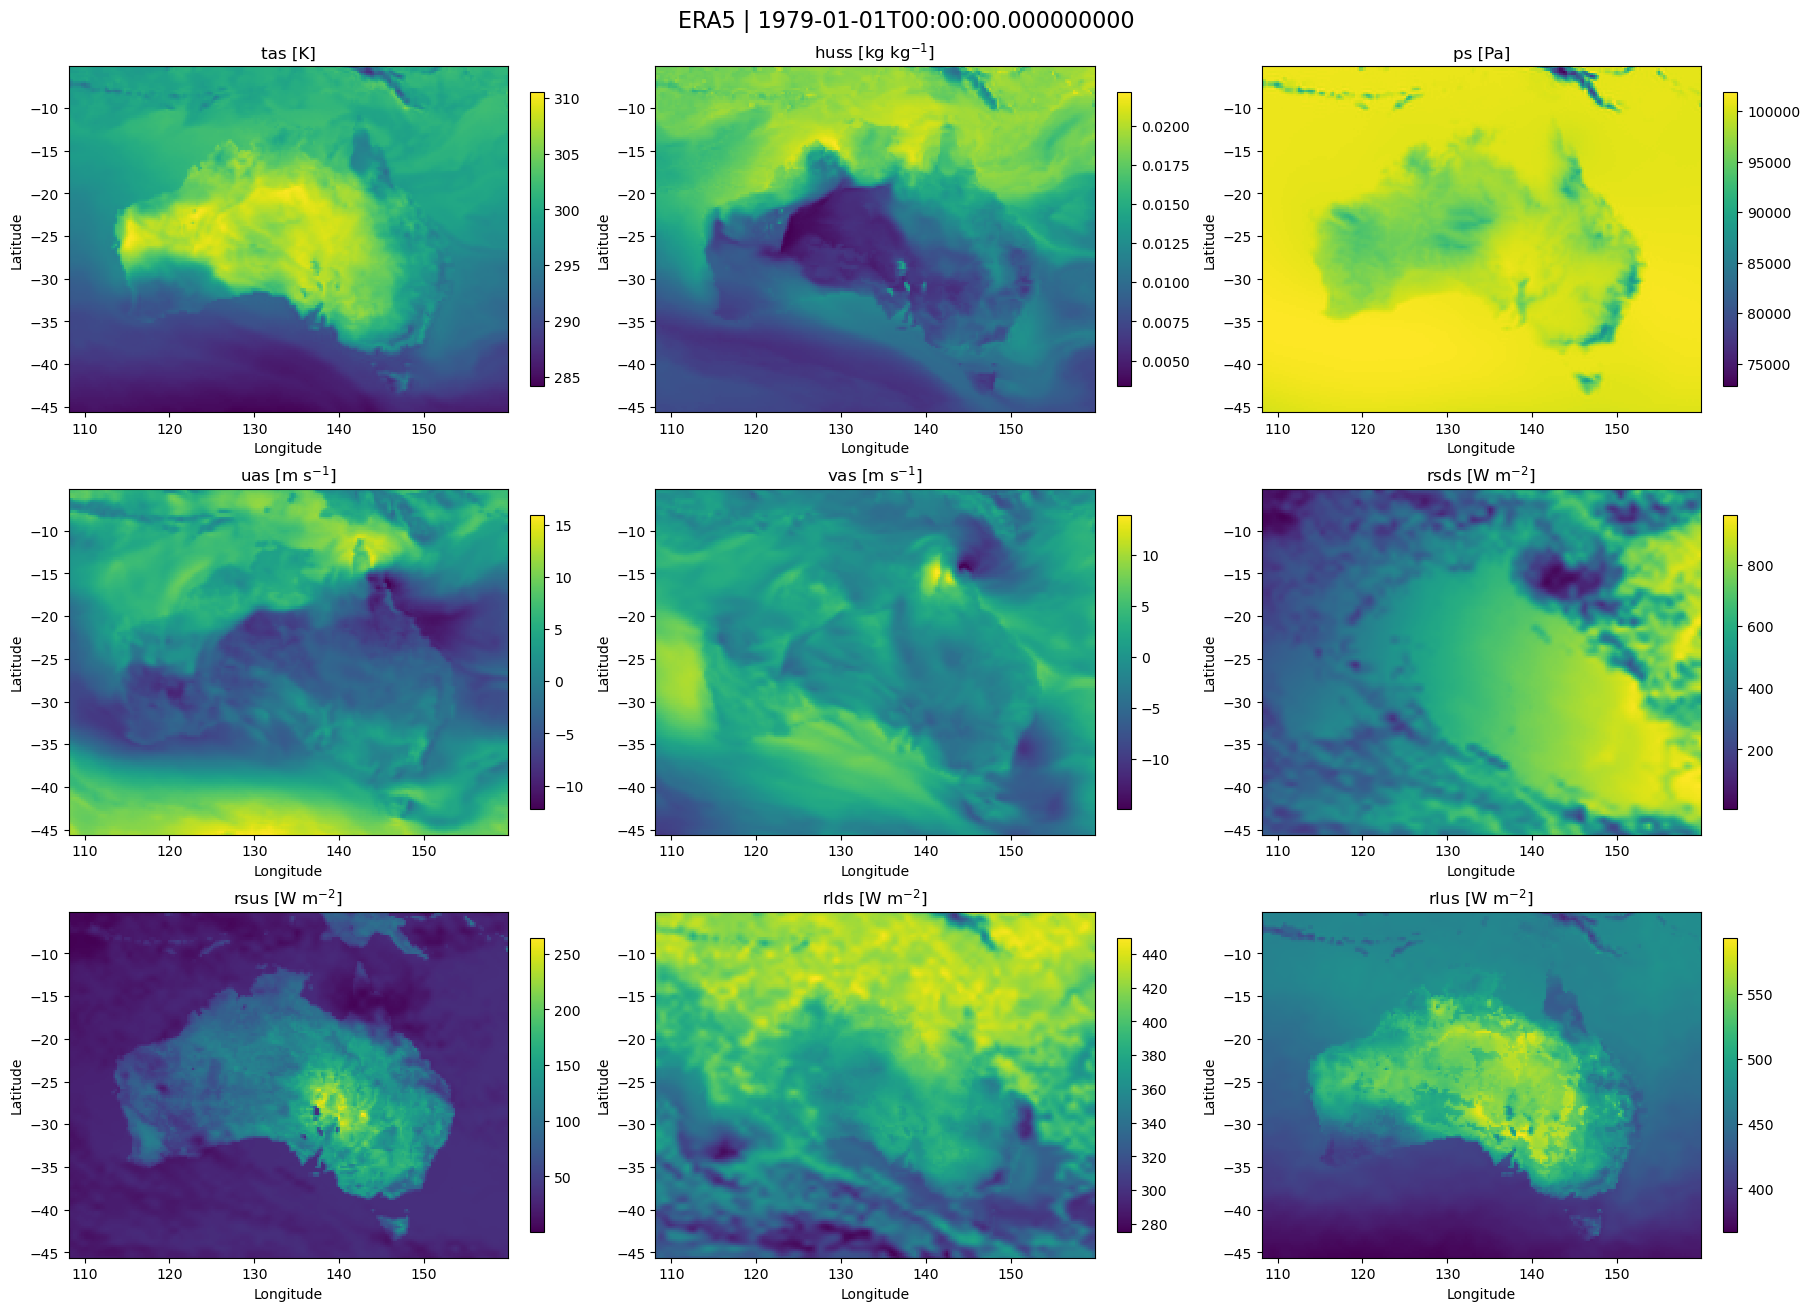

In [40]:
units = [
    "K",          # tas
    "kg kg$^{-1}$", # huss
    "Pa",         # ps
    "m s$^{-1}$", # uas
    "m s$^{-1}$", # vas
    "W m$^{-2}$", # rsds
    "W m$^{-2}$", # rsus
    "W m$^{-2}$", # rlds
    "W m$^{-2}$", # rlus
]

fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 13),
    constrained_layout=True
)

for j, ax in enumerate(axes.flat):

    im = ax.pcolormesh(
        lon,
        lat,
        sample[j],
        shading="auto"
    )

    ax.set_title(
        f"{variables[j]} [{units[j]}]"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    fig.colorbar(
        im,
        ax=ax,
        shrink=0.85
    )

fig.suptitle(
    f"ERA5 | {datetime}",
    fontsize=16
)

plt.show()